In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
sys.path.append('../../')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd

Выгружаем лонг и шорт данные 

In [41]:
# Лонг

import pandas as pd
import datetime as dt
import xgboost as xgb

# args1 = {
#     "iterations": 10000,
#     "depth": 5,
#     "learning_rate": 0.02,
#     "use_best_model": True,
#     "l2_leaf_reg": 200,
#     "loss_function": 'Logloss',
#     "eval_metric": 'Logloss',
#     "cat_features": [],
#     "random_state": 42,
#     "class_weights": [1, 0.25], 
#     "verbose": 0,
#     "early_stopping_rounds": 500
# }

companies_names = ['Gazprom']
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(  # <------------ Вот сюда свою модель вставляем :)
            n_estimators=10000,
            learning_rate=0.02,
            max_depth=5,
            use_label_encoder=False,
            verbose=0,
            eval_metric="logloss",
            random_state=42,
            early_stopping_rounds=500,
            class_weights=[1, 0.01]
        )

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
        )

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid_cw001.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
[0]	validation_0-logloss:0.67057	validation_1-logloss:0.66708
[1]	validation_0-logloss:0.66853	validation_1-logloss:0.66566
[2]	validation_0-logloss:0.66658	validation_1-logloss:0.66426
[3]	validation_0-logloss:0.66467	validation_1-logloss:0.66297
[4]	validation_0-logloss:0.66283	validation_1-logloss:0.66175
[5]	validation_0-logloss:0.66106	validation_1-logloss:0.66053
[6]	validation_0-logloss:0.65932	validation_1-logloss:0.65943
[7]	validation_0-logloss:0.65763	validation_1-logloss:0.65824
[8]	validation_0-logloss:0.65603	validation_1-logloss:0.65710
[9]	validation_0-logloss:0.65447	validation_1-logloss:0.65607
[10]	validation_0-logloss:0.65296	val

In [ ]:
# Шорт

import pandas as pd
import datetime as dt
import optuna 

companies_names = ['Gazprom']
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_1'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        
        model = xgb.XGBClassifier(  # <------------ Вот сюда свою модель вставляем :)
            n_estimators=10000,
            learning_rate=0.02,
            max_depth=5,
            use_label_encoder=False,
            verbose=0,
            eval_metric="logloss",
            random_state=42,
            early_stopping_rounds=500,
            class_weights=[0.25, 1]
        )

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
        )
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_short_valid_cw025.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
[0]	validation_0-logloss:0.66914	validation_1-logloss:0.67286
[1]	validation_0-logloss:0.66754	validation_1-logloss:0.67161
[2]	validation_0-logloss:0.66603	validation_1-logloss:0.67042
[3]	validation_0-logloss:0.66461	validation_1-logloss:0.66938
[4]	validation_0-logloss:0.66320	validation_1-logloss:0.66831
[5]	validation_0-logloss:0.66187	validation_1-logloss:0.66735
[6]	validation_0-logloss:0.66053	validation_1-logloss:0.66628
[7]	validation_0-logloss:0.65927	validation_1-logloss:0.66538
[8]	validation_0-logloss:0.65799	validation_1-logloss:0.66441
[9]	validation_0-logloss:0.65677	validation_1-logloss:0.66334
[10]	validation_0-logloss:0.65559	val

In [ ]:
from catboost import CatBoostClassifier, Pool
import polars as pl
import pandas as pd
import numpy as np
import shap
import optuna 
import datetime as dt
from dateutil.relativedelta import relativedelta
from optuna.pruners import MedianPruner
from optuna.storages import RDBStorage

def optuna_choose_time(self, candles_interval_low = 3000,
                                candles_interval_high = 30000,  
                                number_of_trials = 10,
                                min_trials_for_pruner = 3):
    
    """
    Оптимизирует количество свечей для обучения модели с использованием Optuna.

    Параметры:
        candles_interval_low (int): Минимальное количество свечей для обучения.
        candles_interval_high (int): Максимальное количество свечей для обучения.
        number_of_trials (int): Количество попыток для Optuna.
        min_trials_for_pruner (int): Минимальное количество попыток для активации прунера.

    Исключения:
        ValueError: Выбрасывается, если размер обучающего датасета меньше candles_interval_high.

    Оптимизация проводится с использованием MedianPruner, чтобы исключить малообещающие гипотезы.
    """

    storage = RDBStorage(url="sqlite:///optuna_time_trials.db")
    pruner = MedianPruner(n_min_trials=min_trials_for_pruner)
    len_X_train = self.X_train.shape[0] 

    if len_X_train < candles_interval_high:
            raise ValueError(
                f"Максимальное количество свечей для обучения: {candles_interval_high}. "
                f"Количество свечей в датасете для обучения: {len_X_train}."
            )
    
    def objective(trial):
        nonlocal len_X_train
        num_train_candles = trial.suggest_int("num_train_candles", 
                                        low=candles_interval_low, 
                                        high=candles_interval_high)
        
        current_X_train = self.X_train[len_X_train - num_train_candles : ]
        current_y_train = self.y_train[len_X_train - num_train_candles : ]

        model = CatBoostClassifier(
            **self.args
        )

        pruning_callback = CatBoostPruningCallback(trial, metric=self.args["eval_metric"])

        model.fit(
            current_X_train, 
            current_y_train, 
            eval_set=Pool(self.X_val, self.y_val, cat_features=self.cat), 
            cat_features=self.cat, 
            verbose=1000,  
            callbacks=[pruning_callback]
        )

        pruning_callback.check_pruned()

        accuracy = model.score(self.X_val, self.y_val)
        return accuracy

    study = optuna.create_study(direction="maximize", pruner=pruner, storage=storage, load_if_exists=True)
    study.optimize(objective, n_trials=number_of_trials)

def optuna_choose_params(self, changing_params : dict = {"learning_rate" : {"low" : 0.001, "high" : 0.03},
                                                            "l2_leaf_reg" : {"low" : 3, "high" : 500}, 
                                                            "depth" : {"low" : 3, "high" : 6}},
                                                    min_trials_for_pruner = 3, 
                                                    number_of_trials = 10, n_warmup_steps=0, verbose=1000):
    """
    Оптимизирует гиперпараметры модели CatBoostClassifier с использованием Optuna.

    Параметры:
        changing_params (dict): Словарь параметров для оптимизации. Ключи - названия параметров,
            значения - словари с "low" и "high" границами значений (по умолчанию содержит learning_rate, l2_leaf_reg и depth).
        min_trials_for_pruner (int): Минимальное количество попыток для активации прунера.
        number_of_trials (int): Количество попыток для Optuna.
        n_warmup_steps (int): Количество деревьев до того как прунер начнет прунить.
        verbose (int): Отчет катбуста каждые verbose итераций.

    Пример changing_params:
        {
            "learning_rate": {"low": 0.001, "high": 0.03},
            "l2_leaf_reg": {"low": 3, "high": 500},
            "depth": {"low": 3, "high": 6}
        }

    Оптимизация проводится с использованием MedianPruner, чтобы исключить малообещающие гипотезы.
    """
    
    storage = RDBStorage(url="sqlite:///optuna_params_trials.db")
    pruner = MedianPruner(n_warmup_steps=n_warmup_steps, n_min_trials=min_trials_for_pruner)

    args = self.args

    def objective(trial):
        nonlocal args

        # learning rate
        if changing_params["learning_rate"] is not None:
            suggested_learning_rate = trial.suggest_float("learning_rate", 
                                                        low=changing_params["learning_rate"]["low"], 
                                                        high=changing_params["learning_rate"]["high"])
            args["learning_rate"] = suggested_learning_rate
        
        # regularization
        suggested_l2_leaf_reg = trial.suggest_int("l2_leaf_reg", 
                                                    low=changing_params["l2_leaf_reg"]["low"], 
                                                    high=changing_params["l2_leaf_reg"]["high"])
        args["l2_leaf_reg"] = suggested_l2_leaf_reg

        # depth
        suggested_depth = trial.suggest_int("depth", 
                                            low=changing_params["depth"]["low"], 
                                            high=changing_params["depth"]["high"])
        args["depth"] = suggested_depth

        model = CatBoostClassifier(**args)

        pruning_callback = CatBoostPruningCallback(trial, metric=args["eval_metric"])

        model.fit(
            self.X_train, 
            self.y_train, 
            eval_set=Pool(self.X_val, self.y_val, cat_features=self.cat), 
            cat_features=self.cat, 
            verbose=verbose,  
            callbacks=[pruning_callback]
        )

        pruning_callback.check_pruned()

        accuracy = model.score(self.X_val, self.y_val)
        return accuracy

    study = optuna.create_study(direction="maximize", pruner=pruner, storage=storage, load_if_exists=True)
    study.optimize(objective, n_trials=number_of_trials)

Выгружаем графики метрик

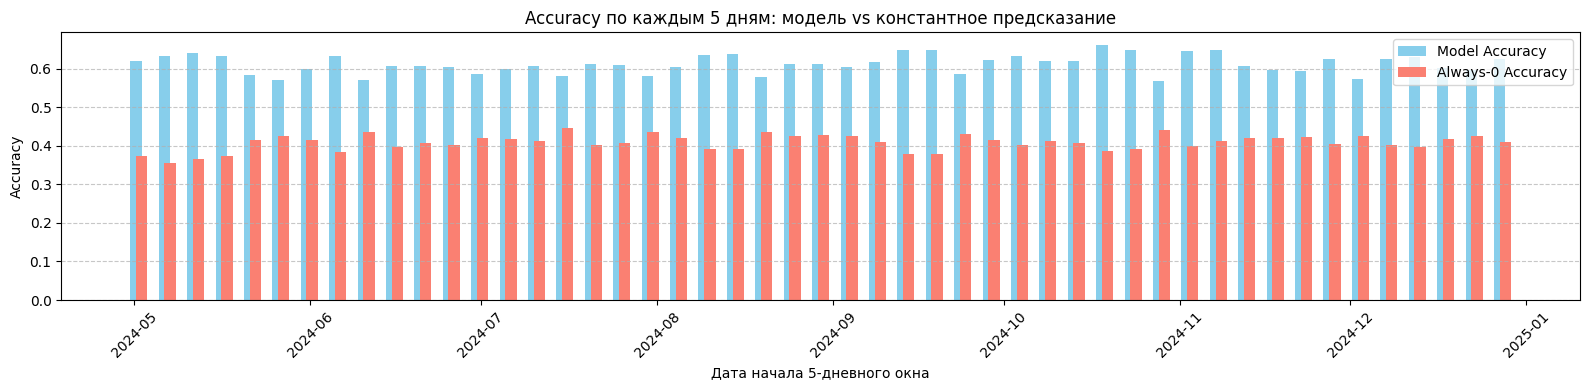

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_short_valid_cw025.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчёта accuracy модели и accuracy "всегда 0"
def compute_group_accuracy(group):
    acc_model = accuracy_score(group['target'], group['pred'])
    acc_dummy0 = accuracy_score(group['target'], [0] * len(group))
    return pd.Series({'accuracy_model': acc_model, 'accuracy_dummy0': acc_dummy0})

# Применяем по группам
grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()

# Добавим дату начала группы
grouped_accuracy['start_date'] = data.groupby('group_id')['utc'].min().values

# Строим barplot
plt.figure(figsize=(16, 4))
bar_width = 4  # Ширина одного столбца (в днях на оси X)

# Координаты по оси X
x = grouped_accuracy['start_date']

# Столбцы с accuracy модели (слева) и dummy (чуть правее)
plt.bar(x, grouped_accuracy['accuracy_model'], 
        width=2, label='Model Accuracy', color='skyblue', align='center')

plt.bar(x, grouped_accuracy['accuracy_dummy0'], 
        width=2, label='Always-0 Accuracy', color='salmon', align='edge')

# Подписи и оформление
plt.title('Accuracy по каждым 5 дням: модель vs константное предсказание')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

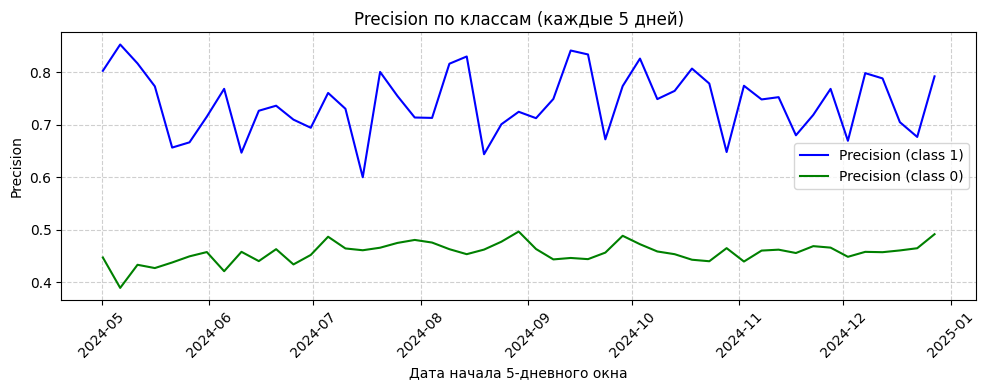

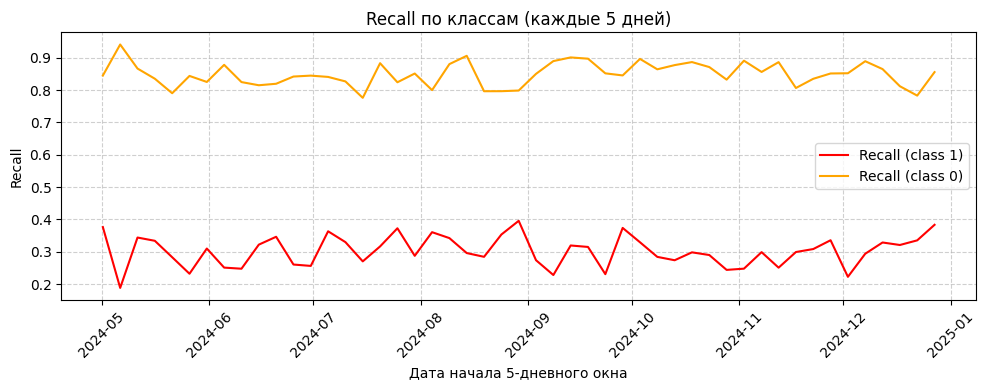

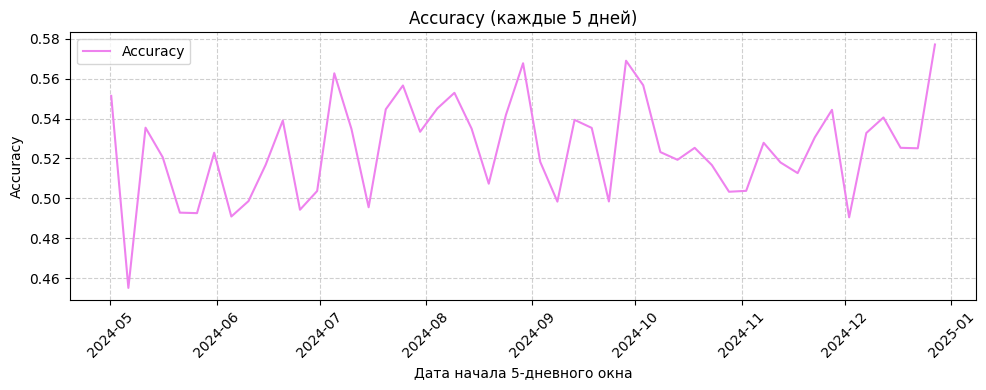

In [39]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_long_valid_cw01.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')


# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)


# Функция для расчета precision и recall по классам
def compute_precision_recall(group):
    y_true = group['target']
    y_pred = group['pred']
    accuracy = accuracy_score(y_true, y_pred)
    precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return pd.Series({
        'precision_1': precision_1,
        'precision_0': precision_0,
        'recall_1': recall_1,
        'recall_0': recall_0,
        'accuracy':  accuracy
    })

# Применяем по группам
metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()

# Добавим дату начала каждой группы
metrics_by_group['start_date'] = data.groupby('group_id')['utc'].min().values

# ----------------------- #
# 1. График Precision     #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_1'], label='Precision (class 1)', color='blue')
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_0'], label='Precision (class 0)', color='green')
plt.title('Precision по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 2. График Recall        #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_1'], label='Recall (class 1)', color='red')
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_0'], label='Recall (class 0)', color='orange')
plt.title('Recall по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 3. График Accuracy       #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['accuracy'], label='Accuracy', color='violet')
plt.title('Accuracy (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

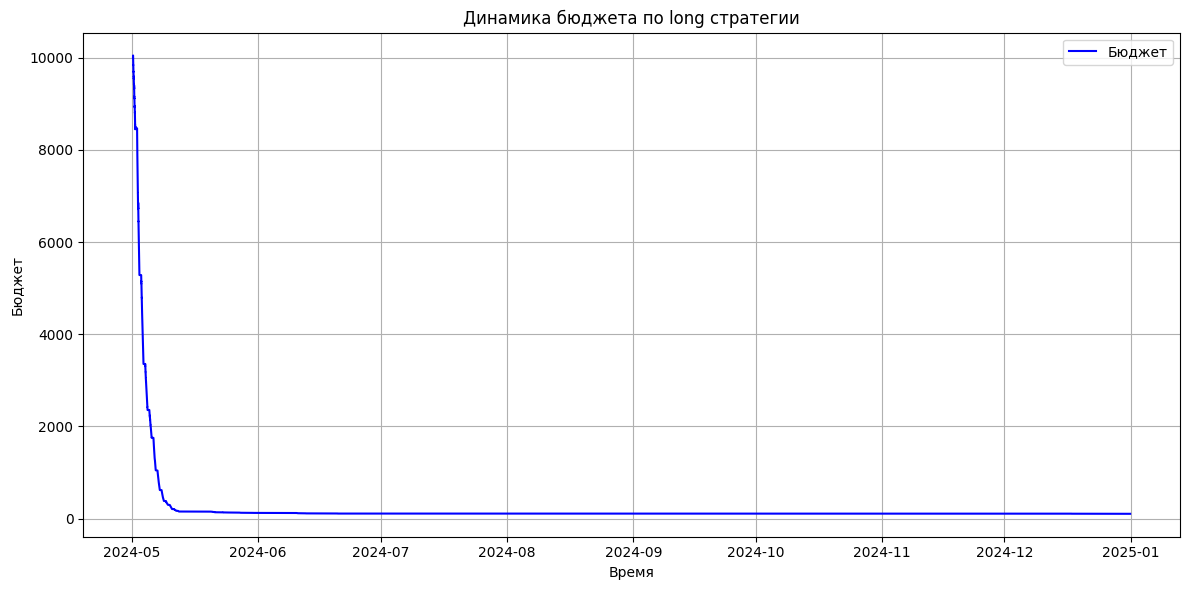

In [40]:
merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    # if signal == 1:  # Long
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         buy_cost = n_shares * price_now * (1 + commission_rate)
    #         sell_revenue = n_shares * price_next * (1 - commission_rate)
    #         budget += sell_revenue - buy_cost

    if signal == 0:  # Short
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            sell_proceeds = n_shares * price_now * (1 - commission_rate)
            buy_cost = n_shares * price_next * (1 + commission_rate)
            budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()